# Fase 1: Geografía y delitos (CDMX)
**Objetivo:** cargar los polígonos oficiales (AGEB urbanas y alcaldías), limpiar los delitos de 2023 y demostrar que los puntos (lat/lon) se integran espacialmente con los polígonos.

**Fuentes:** Marco Geoestadístico del Censo 2020 (INEGI, entidad 09) y Carpetas de investigación FGJ CDMX 2023.

In [1]:
import unicodedata
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from src.config import ROOT, RAW_DIR, PROCESSED_DIR, WORK_CRS

GEO_DIR = RAW_DIR / "09_ciudaddemexico" / "conjunto_de_datos"
CRIMES_CSV = RAW_DIR / "carpetas_fgj_2023.csv"
print("Polígonos:", GEO_DIR.exists(), "| Delitos:", CRIMES_CSV.exists())

Polígonos: True | Delitos: True


## 1. Polígonos: AGEB urbanas y alcaldías

In [2]:
agebs = gpd.read_file(GEO_DIR / "09a.shp")
munis = gpd.read_file(GEO_DIR / "09mun.shp")
print("CRS AGEB     :", agebs.crs)
print("CRS alcaldías:", munis.crs)
print("AGEB urbanas :", len(agebs), "| Alcaldías:", len(munis))
print("Columnas AGEB:", agebs.columns.tolist())
print("Columnas mun :", munis.columns.tolist())
agebs.head(3)

CRS AGEB     : PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
CRS alcaldías: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PAR

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry
0,0901000011716,09,010,0001,1716,"POLYGON ((2787237.541 816989.461, 2787288.728 ..."
1,0901000012150,09,010,0001,2150,"POLYGON ((2794154.458 823013.444, 2794155.774 ..."
2,0901000011133,09,010,0001,1133,"POLYGON ((2795690.723 820050.788, 2795684.238 ..."


### Calidad de la geometría
Revisamos geometrías inválidas o vacías y que la clave `CVEGEO` sea única y de 13 caracteres (entidad 2 + municipio 3 + localidad 4 + AGEB 4).

In [3]:
print("Geometrías inválidas:", (~agebs.is_valid).sum())
print("Geometrías vacías    :", agebs.is_empty.sum())
print("CVEGEO únicos        :", agebs["CVEGEO"].is_unique)
print("Longitudes de CVEGEO :", agebs["CVEGEO"].str.len().unique())

if (~agebs.is_valid).sum() > 0:
    agebs["geometry"] = agebs.make_valid()
    print("Geometrías corregidas con make_valid(). Inválidas ahora:", (~agebs.is_valid).sum())

Geometrías inválidas: 0
Geometrías vacías    : 0
CVEGEO únicos        : True
Longitudes de CVEGEO : [13]


In [4]:
# Área en km2 con un CRS proyectado (para densidades más adelante)
agebs["area_km2"] = agebs.to_crs(WORK_CRS).area / 1e6
agebs["area_km2"].describe()

count    2431.000000
mean        0.327441
std         0.400205
min         0.008844
25%         0.148135
50%         0.232687
75%         0.357049
max         7.431910
Name: area_km2, dtype: float64

## 2. Delitos: carga y limpieza de coordenadas

In [5]:
df = pd.read_csv(CRIMES_CSV, low_memory=False)
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])

df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")

print("Sin latitud o longitud:", df[["latitud", "longitud"]].isna().any(axis=1).sum())
print("Coordenadas en 0      :", ((df["latitud"] == 0) | (df["longitud"] == 0)).sum())
print()
print("Año de inicio:", df["anio_inicio"].value_counts().to_dict())
print("Año del hecho (top 5):", df["anio_hecho"].value_counts().head().to_dict())

Filas: 242392 | Columnas: 22
Sin latitud o longitud: 14147
Coordenadas en 0      : 0

Año de inicio: {2023: 242392}
Año del hecho (top 5): {2023.0: 223163, 2022.0: 13889, 2021.0: 1814, 2020.0: 983, 2019.0: 623}


### Convertir a puntos
Nos quedamos solo con registros con coordenadas válidas, los convertimos a puntos (WGS84, EPSG:4326) y los pasamos al mismo CRS que los polígonos.

In [6]:
validas = df.dropna(subset=["latitud", "longitud"]).copy()
validas = validas[(validas["latitud"] != 0) & (validas["longitud"] != 0)]

pts = gpd.GeoDataFrame(
    validas,
    geometry=gpd.points_from_xy(validas["longitud"], validas["latitud"]),
    crs="EPSG:4326",
).to_crs(agebs.crs)
print("Puntos con coordenadas:", len(pts))
print("Bounds polígonos:", agebs.total_bounds.round(0))
print("Bounds puntos   :", pts.total_bounds.round(0))

Puntos con coordenadas: 228245
Bounds polígonos: [2778446.  794915. 2820181.  846750.]
Bounds puntos   : [2778622.  795174. 2820066.  845264.]


## 3. Spatial join (punto dentro de polígono)
Primero contra las alcaldías, para saber qué puntos caen dentro de la CDMX. Después contra las AGEB urbanas.

In [7]:
# Puntos vs alcaldías
j_mun = gpd.sjoin(pts[["geometry"]], munis[["NOMGEO", "geometry"]], how="left", predicate="within")
j_mun = j_mun[~j_mun.index.duplicated(keep="first")]
pts["dentro_cdmx"] = j_mun["NOMGEO"].notna()
pts["alcaldia_geo"] = j_mun["NOMGEO"]

# Puntos vs AGEB urbanas
j_ageb = gpd.sjoin(pts[["geometry"]], agebs[["CVEGEO", "geometry"]], how="left", predicate="within")
j_ageb = j_ageb[~j_ageb.index.duplicated(keep="first")]
pts["CVEGEO"] = j_ageb["CVEGEO"]

resumen = pd.Series({
    "Registros totales": len(df),
    "Sin coordenadas válidas": len(df) - len(pts),
    "Con coordenadas, fuera de la CDMX": int((~pts["dentro_cdmx"]).sum()),
    "Dentro de la CDMX, fuera de AGEB urbana": int((pts["dentro_cdmx"] & pts["CVEGEO"].isna()).sum()),
    "Asignados a una AGEB urbana": int(pts["CVEGEO"].notna().sum()),
})
resumen = resumen.to_frame("n")
resumen["% del total"] = (resumen["n"] / len(df) * 100).round(2)
resumen

,n,% del total
Registros totales,242392,100.00
Sin coordenadas válidas,14147,5.84
"Con coordenadas, fuera de la CDMX",51,0.02
"Dentro de la CDMX, fuera de AGEB urbana",357,0.15
Asignados a una AGEB urbana,227837,94.00


### Validación cruzada
Comparamos la alcaldía que dice el CSV (`alcaldia_catalogo`) con la que resulta del spatial join. Si coinciden en un porcentaje alto, la integración espacial es confiable.

In [8]:
def norm(s):
    if pd.isna(s):
        return None
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower().strip()
    return s

dentro = pts[pts["dentro_cdmx"]].copy()
coinciden = dentro["alcaldia_catalogo"].map(norm) == dentro["alcaldia_geo"].map(norm)
print(f"Coincidencia alcaldía CSV vs spatial join: {coinciden.mean() * 100:.2f}% ({coinciden.sum()} de {len(dentro)})")

# Ejemplos que no coinciden
dentro.loc[~coinciden, ["alcaldia_catalogo", "alcaldia_geo"]].value_counts().head(10)

Coincidencia alcaldía CSV vs spatial join: 99.86% (227880 de 228194)


alcaldia_catalogo    alcaldia_geo         
Iztacalco            Venustiano Carranza      45
Venustiano Carranza  Cuauhtémoc               34
Iztapalapa           Iztacalco                23
Álvaro Obregón       Cuajimalpa de Morelos    16
Iztapalapa           Xochimilco               12
Tlalpan              Coyoacán                 12
Xochimilco           Tlalpan                  11
Cuauhtémoc           Miguel Hidalgo           11
Coyoacán             Álvaro Obregón            9
Gustavo A. Madero    Azcapotzalco              9
Name: count, dtype: int64

## 4. Delitos por AGEB y mapa

In [9]:
conteo = pts.dropna(subset=["CVEGEO"]).groupby("CVEGEO").size().rename("n_delitos")
agebs = agebs.merge(conteo, on="CVEGEO", how="left")
agebs["n_delitos"] = agebs["n_delitos"].fillna(0).astype(int)

print("AGEB con al menos 1 delito:", (agebs["n_delitos"] > 0).sum(), "de", len(agebs))
agebs["n_delitos"].describe()

AGEB con al menos 1 delito: 2420 de 2431


count    2431.000000
mean       93.721514
std        91.345445
min         0.000000
25%        41.000000
50%        72.000000
75%       118.000000
max      1480.000000
Name: n_delitos, dtype: float64

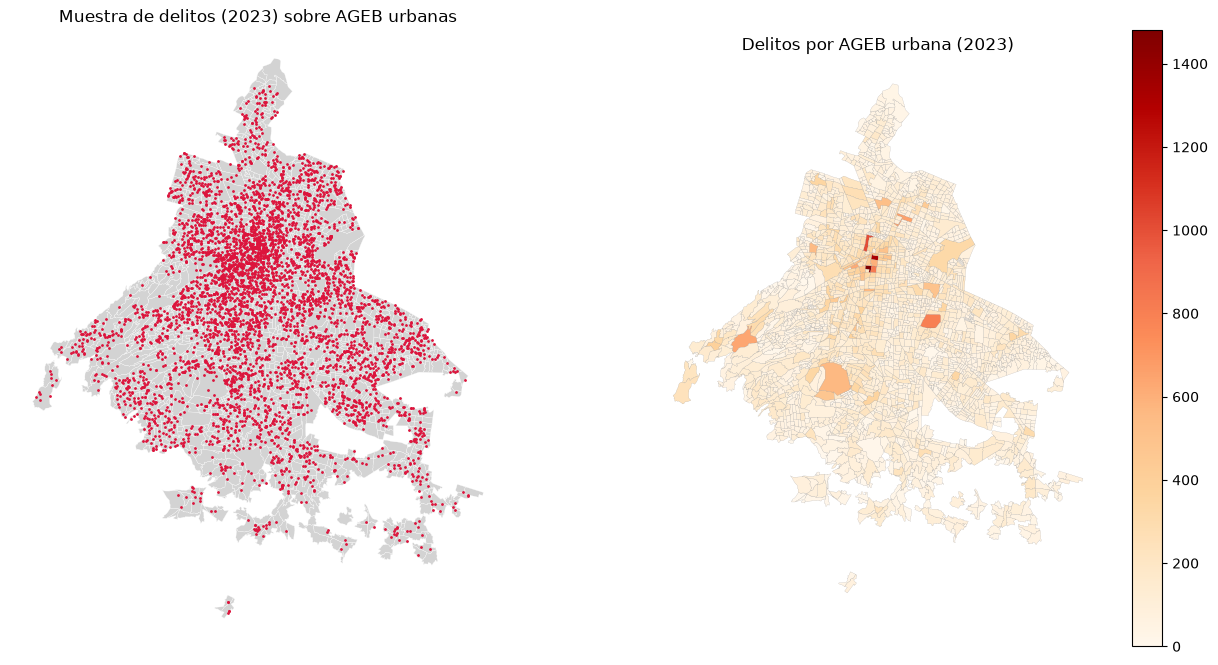

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

agebs.plot(ax=axes[0], color="lightgrey", edgecolor="white", linewidth=0.2)
pts[pts["CVEGEO"].notna()].sample(min(5000, int(pts["CVEGEO"].notna().sum())), random_state=1) \
    .plot(ax=axes[0], markersize=1, color="crimson")
axes[0].set_title("Muestra de delitos (2023) sobre AGEB urbanas")

agebs.plot(column="n_delitos", ax=axes[1], cmap="OrRd", legend=True, linewidth=0.1, edgecolor="grey")
axes[1].set_title("Delitos por AGEB urbana (2023)")

for ax in axes:
    ax.set_axis_off()

out_dir = ROOT / "outputs" / "maps"
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "fase1_delitos_por_ageb.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Guardar resultados procesados (no se suben a Git)

In [11]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pts.to_file(PROCESSED_DIR / "delitos_2023_ageb.gpkg", layer="delitos", driver="GPKG")
agebs.to_file(PROCESSED_DIR / "agebs_urbanas_cdmx.gpkg", layer="agebs", driver="GPKG")
print("Guardado en", PROCESSED_DIR)

Guardado en /work/data/processed


## Conclusiones de la Fase 1
- **Unidad geográfica elegida:** AGEB urbana (justificación en el README).
- **Integración lat/lon -> polígono:** 227,837 de 242,392 delitos (94.00%) quedaron asignados a una AGEB urbana.
- **Calidad de datos:** 14,147 registros sin coordenadas válidas (5.84%), 51 con coordenadas fuera de la CDMX y 357 dentro de la CDMX pero en zonas sin AGEB urbana.
- **Validación cruzada de alcaldía:** 99.86% de coincidencia entre la alcaldía del CSV y la obtenida por spatial join.
- **Limitaciones:** el Censo por AGEB cubre solo zonas urbanas; desfase temporal entre fuentes (Censo 2020, delitos 2023).
  
